# Distillation Results — v7

This notebook loads the evaluated distillation combinations:
3 teachers × 4 students × 3 conditions.

Local JSONL files are the primary source of truth. Runtime and throughput statistics are pulled from the matching WandB run summaries when present, and the notebook falls back to the WandB API only if a local summary is missing.


In [9]:
from __future__ import annotations

import json
import re
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

try:
    import wandb
except ImportError:
    wandb = None

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path("../../").resolve()
RESULTS_ROOT = PROJECT_ROOT / "data/safety_experiment/distillation"
WANDB_ROOT = PROJECT_ROOT / "logs/wandb/wandb"
WANDB_ENTITY = "Jazhyc"
WANDB_PROJECT = "Distillation Results"

TEACHERS = {
    "cyankiwi-Mistral-Small-4-119B-2603-AWQ-4bit": "Mistral Small 4 119B",
    "Qwen-Qwen3-32B": "Qwen3 32B",
    "openai-gpt-oss-120b": "GPT-OSS 120B",
    "RedHatAI-gemma-3-27b-it-quantized.w4a16": "Gemma 3 27B",
}

STUDENTS = {
    "gemma-3-12b": "Gemma 3 12B",
    "llama-3.1-8b": "Llama 3.1 8B",
    # Ministral 3 14B excluded: training never converged (~70% empty val outputs)
    # due to Mistral V7 chat template having no assistant-turn opener for SFT to anchor on.
    "qwen3-8b": "Qwen3 8B",
}

CONDITIONS = {
    "no_intent": "No Intent",
    "synthetic_intent": "Synthetic Intent",
    "human_intent": "Human Intent",
}

DATASETS = {
    "aegis": "Aegis",
    "annotated-intents": "Annotated Intents",
    "openai-moderation": "OpenAI Moderation",
    "toxic-chat": "Toxic Chat",
    "wildguardmix": "WildGuardMix",
    "xstest": "XSTest",
}

# Distillation eval runs log metrics under eval-condition keys, not training-condition slugs.
EVAL_SUFFIX = {
    "no_intent": "finetuned_reasoning_classification",
    "synthetic_intent": "finetuned_reasoning_synthetic_intent",
    "human_intent": "finetuned_reasoning_human_intent",
}

TEACHER_ORDER = list(TEACHERS.keys())
STUDENT_ORDER = list(STUDENTS.keys())
CONDITION_ORDER = list(CONDITIONS.keys())
DATASET_ORDER = list(DATASETS.keys())


def _to_binary_label(value):
    if value is None:
        return None
    if isinstance(value, bool):
        return 1 if value else 0
    if isinstance(value, (int, float)):
        return int(value)

    text = str(value).strip().lower()
    if text in {"harmful", "unsafe", "1", "true", "yes"}:
        return 1
    if text in {"safe", "benign", "0", "false", "no"}:
        return 0
    return None


def find_jsonl_file(dataset_dir: Path) -> Path | None:
    if not dataset_dir.exists():
        return None

    preferred = sorted(dataset_dir.glob("*_classification.jsonl"))
    if preferred:
        return preferred[0]

    any_jsonl = sorted(dataset_dir.glob("*.jsonl"))
    if any_jsonl:
        return any_jsonl[0]

    return None


def compute_binary_metrics(jsonl_path: Path) -> dict:
    y_true = []
    y_pred = []
    missing_predictions = 0
    num_rows = 0
    total_tokens = 0

    with open(jsonl_path) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            num_rows += 1
            record = json.loads(line)
            total_tokens += record.get("num_tokens", 0) or 0

            true_value = (
                record.get("true_harm_binary")
                if record.get("true_harm_binary") is not None
                else record.get("true_harm")
            )
            pred_value = (
                record.get("predicted_harm")
                if record.get("predicted_harm") is not None
                else record.get("pred_harm")
            )

            y_t = _to_binary_label(true_value)
            y_p = _to_binary_label(pred_value)

            if y_t is None:
                missing_predictions += 1
                continue
            if y_p is None:
                # Treat parse failure as "safe" — the model failed to flag.
                missing_predictions += 1
                y_p = 0

            y_true.append(y_t)
            y_pred.append(y_p)

    num_scored = len(y_true)
    if num_scored == 0:
        return {
            "num_rows": num_rows,
            "num_scored": 0,
            "missing_predictions": missing_predictions,
            "total_tokens": total_tokens,
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
        }

    return {
        "num_rows": num_rows,
        "num_scored": num_scored,
        "missing_predictions": missing_predictions,
        "total_tokens": total_tokens,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def _extract_run_name_from_config(config_path: Path) -> str | None:
    try:
        with open(config_path) as handle:
            for raw_line in handle:
                line = raw_line.strip()
                if line.startswith("run_name:"):
                    return line.split(":", 1)[1].strip().strip("\"'")
    except Exception:
        return None
    return None


def _run_name_from_api_run(run) -> str | None:
    cfg = run.config or {}
    candidates = [
        cfg.get("run_name"),
        cfg.get("wandb.run_name"),
        cfg.get("wandb", {}).get("run_name") if isinstance(cfg.get("wandb"), dict) else None,
        getattr(run, "display_name", None),
        getattr(run, "name", None),
    ]
    for candidate in candidates:
        if isinstance(candidate, str) and candidate.startswith("distill--"):
            return candidate
    return None


@lru_cache(maxsize=1)
def _api_summary_index() -> dict[str, dict]:
    index: dict[str, dict] = {}
    if wandb is None:
        return index

    api = wandb.Api()
    runs = api.runs(path=f"{WANDB_ENTITY}/{WANDB_PROJECT}")
    for run in runs:
        run_name = _run_name_from_api_run(run)
        if not run_name:
            continue
        summary = dict(run.summary)
        summary["_source"] = "api"
        summary["_wandb_run_id"] = run.id
        summary["_wandb_run_name"] = run_name
        index[run_name] = summary
    return index


@lru_cache(maxsize=1)
def _local_summary_index() -> dict[str, dict]:
    index: dict[str, dict] = {}
    if not WANDB_ROOT.exists():
        return index

    # Sort paths so newer runs (larger timestamp in dir name) are processed last,
    # giving them priority when elapsed_s counts are tied.
    for summary_path in sorted(WANDB_ROOT.glob("run-*/files/wandb-summary.json")):
        run_files_dir = summary_path.parent
        config_path = run_files_dir / "config.yaml"
        run_name = _extract_run_name_from_config(config_path)
        if not run_name:
            continue
        try:
            with open(summary_path) as handle:
                payload = json.load(handle)
            payload["_source"] = "local"
            payload["_local_summary_path"] = str(summary_path)
            # When multiple run dirs share the same run_name (re-runs), prefer the
            # summary with the most elapsed_s keys — that is the most complete run.
            existing = index.get(run_name)
            if existing is None:
                index[run_name] = payload
            else:
                new_elapsed = sum(1 for k in payload if isinstance(k, str) and k.endswith("/elapsed_s"))
                old_elapsed = sum(1 for k in existing if isinstance(k, str) and k.endswith("/elapsed_s"))
                if new_elapsed >= old_elapsed:
                    index[run_name] = payload
        except Exception:
            continue
    return index


@lru_cache(maxsize=None)
def load_run_summary(run_name: str) -> dict:
    api_summary = None
    try:
        api_summary = _api_summary_index().get(run_name)
    except Exception:
        pass

    local_summary = _local_summary_index().get(run_name)

    if api_summary is None and local_summary is None:
        return {"_source": "missing"}
    if api_summary is None:
        return local_summary
    if local_summary is None:
        return api_summary

    # Both present: merge so neither source loses data the other has.
    # Local fills in keys missing from the API summary (e.g. elapsed_s when API
    # sync is incomplete); API values take priority for any key present in both.
    merged = {**local_summary, **api_summary}
    merged["_source"] = "api+local"
    return merged


def summary_stat(summary: dict, key: str):
    value = summary.get(key)
    if value is not None:
        return value
    if key == "runtime" and summary.get("_runtime") is not None:
        return summary.get("_runtime")
    wandb_meta = summary.get("_wandb")
    if isinstance(wandb_meta, dict):
        return wandb_meta.get(key)
    return None



# ── OOD validation F1 ─────────────────────────────────────────────────────────

OOD_VAL_ROOT = PROJECT_ROOT / "data" / "safety_experiment" / "ood_validation" / "distillation"
OOD_VAL_DATASETS = {"toxic-chat": "Toxic Chat", "aegis": "Aegis"}
OOD_VAL_F1_CACHE_PATH = PROJECT_ROOT / "data" / "cache" / "ood_val_f1_index.json"
OOD_VAL_WANDB_PROJECT = "OOD Validation"


@lru_cache(maxsize=1)
def _ood_val_summary_index() -> dict[str, dict]:
    """Query the OOD Validation W&B project for runtime metrics keyed by run name."""
    index: dict[str, dict] = {}
    if wandb is None:
        return index
    try:
        api = wandb.Api()
        runs = api.runs(path=f"{WANDB_ENTITY}/{OOD_VAL_WANDB_PROJECT}")
    except Exception:
        return index
    for run in runs:
        run_name = (run.config or {}).get("wandb", {}).get("run_name") if isinstance((run.config or {}).get("wandb"), dict) else None
        run_name = run_name or getattr(run, "display_name", None) or getattr(run, "name", None)
        if not run_name:
            continue
        index[run_name] = dict(run.summary)
    return index


def _compute_jsonl_f1(jsonl_path: Path) -> dict | None:
    if not jsonl_path.exists():
        return None
    y_true, y_pred = [], []
    total_tokens = 0
    total_records = 0
    with open(jsonl_path) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            total_records += 1
            total_tokens += record.get("num_tokens", 0) or 0
            true_value = record.get("true_harm_binary") if record.get("true_harm_binary") is not None else record.get("true_harm")
            pred_value = record.get("predicted_harm") if record.get("predicted_harm") is not None else record.get("pred_harm")
            t = _to_binary_label(true_value)
            p = _to_binary_label(pred_value)
            if t is None:
                continue
            if p is None:
                p = 0  # parse failure → "safe"
            y_true.append(t)
            y_pred.append(p)
    if not y_true:
        return None
    return {
        "accuracy":     accuracy_score(y_true, y_pred),
        "precision":    precision_score(y_true, y_pred, zero_division=0),
        "recall":       recall_score(y_true, y_pred, zero_division=0),
        "f1":           f1_score(y_true, y_pred, zero_division=0),
        "n":            len(y_true),
        "total_tokens": total_tokens,
        "total_records": total_records,
    }


def load_ood_val_records() -> pd.DataFrame:
    """Per (teacher × student × condition × OOD dataset) F1 from JSONL outputs.

    For each combination we use the most recently written adapter directory under
    OOD_VAL_ROOT (typically only one — submit_distillation_eval.py picks the best
    LR per combination — but we tolerate stale dirs from prior runs).
    """
    rows = []
    if not OOD_VAL_ROOT.exists():
        return pd.DataFrame(rows)

    for teacher_slug, teacher_name in TEACHERS.items():
        for student_slug, student_name in STUDENTS.items():
            for condition_slug, condition_name in CONDITIONS.items():
                combo_dir = OOD_VAL_ROOT / teacher_slug / student_slug / condition_slug
                if not combo_dir.exists():
                    continue
                adapter_dirs = [p for p in combo_dir.iterdir() if p.is_dir()]
                if not adapter_dirs:
                    continue
                adapter_dir = max(adapter_dirs, key=lambda p: p.stat().st_mtime)

                for ds_slug, ds_name in OOD_VAL_DATASETS.items():
                    ds_dir = adapter_dir / ds_slug
                    if not ds_dir.exists():
                        continue
                    jsonl = next(iter(sorted(ds_dir.glob("*.jsonl"))), None)
                    if jsonl is None:
                        continue
                    metrics = _compute_jsonl_f1(jsonl)
                    if metrics is None:
                        continue
                    # Look up wallclock from the OOD Validation W&B run for this adapter+dataset.
                    run_name = f"distill-ood-val--{teacher_slug}--{student_slug}--{condition_slug}--{adapter_dir.name}"
                    summary = _ood_val_summary_index().get(run_name, {})
                    eval_cond = EVAL_SUFFIX[condition_slug]
                    elapsed_s = summary.get(f"{ds_slug}/{eval_cond}/elapsed_s")
                    rows.append({
                        "teacher_slug":   teacher_slug,
                        "teacher":        teacher_name,
                        "student_slug":   student_slug,
                        "student":        student_name,
                        "condition_slug": condition_slug,
                        "condition":      condition_name,
                        "dataset_slug":   ds_slug,
                        "dataset":        ds_name,
                        "adapter_dir":    str(adapter_dir.relative_to(PROJECT_ROOT)),
                        "jsonl_path":     str(jsonl.relative_to(PROJECT_ROOT)),
                        "elapsed_s":      pd.to_numeric(elapsed_s, errors="coerce"),
                        **metrics,
                    })

    return pd.DataFrame(rows)



def load_combo_rows() -> tuple[pd.DataFrame, list[str]]:
    rows = []
    missing = []

    for teacher_slug, teacher_name in TEACHERS.items():
        for student_slug, student_name in STUDENTS.items():
            for condition_slug, condition_name in CONDITIONS.items():
                combo_dir = RESULTS_ROOT / teacher_slug / student_slug / condition_slug
                run_name = f"distill--{teacher_slug}--{student_slug}--{condition_slug}"
                summary = load_run_summary(run_name)

                if not combo_dir.exists():
                    missing.append(f"{teacher_slug}/{student_slug}/{condition_slug}: missing combo directory")
                    continue

                for dataset_slug, dataset_name in DATASETS.items():
                    dataset_dir = combo_dir / dataset_slug
                    jsonl_path = find_jsonl_file(dataset_dir)
                    if jsonl_path is None:
                        missing.append(f"{teacher_slug}/{student_slug}/{condition_slug}/{dataset_slug}: missing JSONL")
                        continue

                    metrics = compute_binary_metrics(jsonl_path)
                    eval_suffix = EVAL_SUFFIX[condition_slug]
                    prefix = f"{dataset_slug}/{eval_suffix}"
                    wandb_elapsed_s = summary.get(f"{prefix}/elapsed_s")
                    wandb_total_tokens = summary.get(f"{prefix}/total_tokens")
                    wandb_tokens_per_second = summary.get(f"{prefix}/tokens_per_second")

                    rows.append(
                        {
                            "teacher_slug": teacher_slug,
                            "teacher": teacher_name,
                            "student_slug": student_slug,
                            "student": student_name,
                            "condition_slug": condition_slug,
                            "condition": condition_name,
                            "dataset_slug": dataset_slug,
                            "dataset": dataset_name,
                            "run_name": run_name,
                            "jsonl_path": str(jsonl_path.relative_to(PROJECT_ROOT)),
                            "wandb_source": summary.get("_source", "missing"),
                            "wandb_runtime_s": summary_stat(summary, "runtime"),
                            "wandb_elapsed_s": wandb_elapsed_s,
                            "wandb_tokens_per_second": wandb_tokens_per_second,
                            **metrics,
                        }
                    )

    return pd.DataFrame(rows), missing

In [ ]:
WANDB_ENTITY = "intention-analysis"
WANDB_PROJECT = "Distillation Results"

_api_summary_index.cache_clear()
load_run_summary.cache_clear()

records_df, missing_items = load_combo_rows()

expected_combos = len(TEACHERS) * len(STUDENTS) * len(CONDITIONS)
expected_rows = expected_combos * len(DATASETS)

if records_df.empty:
    raise RuntimeError("No distillation results were found.")

ood_val_df = load_ood_val_records()
if ood_val_df.empty:
    print("[warn] No OOD validation results found under data/safety_experiment/ood_validation/distillation/")

ood_val_combo = (
    ood_val_df.groupby(["teacher_slug", "student_slug", "condition_slug"], as_index=False)["f1"]
    .mean()
    .rename(columns={"f1": "ood_val_harm_f1"})
)

# Aggregate OOD-val token & timing stats per (teacher, student, condition) — summed across both OOD datasets.
if not ood_val_df.empty:
    ood_val_runtime = (
        ood_val_df.groupby(["teacher_slug", "student_slug", "condition_slug"], as_index=False)
        .agg(
            ood_val_total_tokens=("total_tokens", "sum"),
            ood_val_total_records=("total_records", "sum"),
            ood_val_total_elapsed_s=("elapsed_s", "sum"),
        )
    )
else:
    ood_val_runtime = pd.DataFrame(columns=[
        "teacher_slug", "student_slug", "condition_slug",
        "ood_val_total_tokens", "ood_val_total_records", "ood_val_total_elapsed_s",
    ])

# Full cartesian frame of every (teacher × student × condition) — 48 rows.
combo_df = pd.DataFrame(
    [
        {
            "teacher_slug":   teacher_slug,
            "teacher":        teacher_name,
            "student_slug":   student_slug,
            "student":        student_name,
            "condition_slug": condition_slug,
            "condition":      condition_name,
            "run_name":       f"distill--{teacher_slug}--{student_slug}--{condition_slug}",
        }
        for teacher_slug, teacher_name in TEACHERS.items()
        for student_slug, student_name in STUDENTS.items()
        for condition_slug, condition_name in CONDITIONS.items()
    ]
)

# Test-set aggregates (only populated for combos with JSONL outputs).
if not records_df.empty:
    test_aggregates = (
        records_df.groupby(
            ["teacher_slug", "student_slug", "condition_slug", "wandb_source"],
            as_index=False,
        )
        .agg(
            datasets_loaded=("dataset_slug", "nunique"),
            files_loaded=("jsonl_path", "count"),
            mean_accuracy=("accuracy", "mean"),
            mean_precision=("precision", "mean"),
            mean_recall=("recall", "mean"),
            mean_f1=("f1", "mean"),
            total_rows=("num_rows", "sum"),
            scored_rows=("num_scored", "sum"),
            missing_predictions=("missing_predictions", "sum"),
            total_tokens=("total_tokens", "sum"),
            total_elapsed_s=("wandb_elapsed_s", "sum"),
            wandb_runtime_s=("wandb_runtime_s", "first"),
        )
    )
    combo_df = combo_df.merge(
        test_aggregates,
        on=["teacher_slug", "student_slug", "condition_slug"],
        how="left",
    )
else:
    combo_df["wandb_source"] = "missing"
    for col in ["datasets_loaded", "files_loaded", "mean_accuracy", "mean_precision",
                "mean_recall", "mean_f1", "total_rows", "scored_rows",
                "missing_predictions", "total_tokens", "total_elapsed_s",
                "wandb_runtime_s"]:
        combo_df[col] = np.nan

combo_df["wandb_source"] = combo_df["wandb_source"].fillna("missing")

# OOD validation F1 — left-merge so missing combos stay as NaN.
combo_df = combo_df.merge(ood_val_combo, on=["teacher_slug", "student_slug", "condition_slug"], how="left")
combo_df = combo_df.merge(ood_val_runtime, on=["teacher_slug", "student_slug", "condition_slug"], how="left")

_elapsed_denom = combo_df["total_elapsed_s"].replace(0, np.nan)
combo_df["computed_tokens_per_second"] = combo_df["total_tokens"] / _elapsed_denom

combo_df = combo_df.assign(
    teacher_rank=combo_df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}),
    student_rank=combo_df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}),
    condition_rank=combo_df["condition_slug"].map({slug: idx for idx, slug in enumerate(CONDITION_ORDER)}),
).sort_values(["teacher_rank", "student_rank", "condition_rank"]).drop(columns=["teacher_rank", "student_rank", "condition_rank"])

records_df = records_df.assign(
    teacher_rank=records_df["teacher_slug"].map({slug: idx for idx, slug in enumerate(TEACHER_ORDER)}),
    student_rank=records_df["student_slug"].map({slug: idx for idx, slug in enumerate(STUDENT_ORDER)}),
    condition_rank=records_df["condition_slug"].map({slug: idx for idx, slug in enumerate(CONDITION_ORDER)}),
    dataset_rank=records_df["dataset_slug"].map({slug: idx for idx, slug in enumerate(DATASET_ORDER)}),
).sort_values(["teacher_rank", "student_rank", "condition_rank", "dataset_rank"]).drop(columns=["teacher_rank", "student_rank", "condition_rank", "dataset_rank"])

print(f"Loaded {len(combo_df)}/{expected_combos} combinations and {len(records_df)}/{expected_rows} dataset files.")
print(f"WandB source counts: {combo_df['wandb_source'].value_counts(dropna=False).to_dict()}")
if missing_items:
    print("Missing items:")
    for item in missing_items:
        print(f"  - {item}")

combo_display = combo_df[[
    "teacher",
    "student",
    "condition",
    "datasets_loaded",
    "mean_accuracy",
    "mean_precision",
    "mean_recall",
    "mean_f1",
    "total_tokens",
    "total_elapsed_s",
    "computed_tokens_per_second",
    "wandb_runtime_s",
    "wandb_source",
]]

combo_display = combo_display.rename(columns={
    "mean_accuracy": "accuracy",
    "mean_precision": "precision",
    "mean_recall": "recall",
    "mean_f1": "f1",
    "total_tokens": "tokens",
    "total_elapsed_s": "elapsed_s",
    "computed_tokens_per_second": "tok_per_s",
    "wandb_runtime_s": "wandb_runtime_s",
})

for col in ["accuracy", "precision", "recall", "f1", "tokens", "elapsed_s", "tok_per_s", "wandb_runtime_s"]:
    combo_display[col] = pd.to_numeric(combo_display[col], errors="coerce")

display(
    combo_display.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "tokens": "{:.0f}",
        "elapsed_s": "{:.1f}",
        "tok_per_s": "{:.1f}",
        "wandb_runtime_s": "{:.0f}",
    })
)

print("\nDataset-level details (first 12 rows):")
records_preview = records_df[[
    "teacher",
    "student",
    "condition",
    "dataset",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "num_rows",
    "missing_predictions",
    "wandb_elapsed_s",
    "total_tokens",
    "wandb_tokens_per_second",
]].head(12).copy()

for col in ["accuracy", "precision", "recall", "f1", "wandb_elapsed_s", "total_tokens", "wandb_tokens_per_second"]:
    records_preview[col] = pd.to_numeric(records_preview[col], errors="coerce")

display(
    records_preview.style.format({
        "accuracy": "{:.3f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "wandb_elapsed_s": "{:.1f}",
        "total_tokens": "{:.0f}",
        "wandb_tokens_per_second": "{:.1f}",
    })
)

FIGURES_DIR = PROJECT_ROOT / "notebooks" / "distillation" / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
axes[1].yaxis.set_visible(False)
axes[2].yaxis.set_visible(False)
heatmap_min = float(combo_df['ood_val_harm_f1'].min(skipna=True))
heatmap_max = float(combo_df['ood_val_harm_f1'].max(skipna=True))
cmap = sns.color_palette("crest", as_cmap=True)
for ax, condition_slug in zip(axes, CONDITION_ORDER):
    pivot = (
        combo_df[combo_df["condition_slug"] == condition_slug]
        .pivot(index="teacher", columns="student", values="ood_val_harm_f1")
        .reindex(index=[TEACHERS[k] for k in TEACHER_ORDER], columns=[STUDENTS[k] for k in STUDENT_ORDER])
    )
    image = ax.imshow(pivot.values, vmin=heatmap_min, vmax=heatmap_max, cmap=cmap)
    ax.set_title(CONDITIONS[condition_slug], pad=10)
    ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            cell_value = pivot.iloc[i, j]
            if pd.isna(cell_value):
                ax.text(j, i, "—", ha="center", va="center", color="#888", fontsize=8)
                continue
            norm_val = (cell_value - heatmap_min) / (heatmap_max - heatmap_min + 1e-12)
            text_color = "white" if norm_val > 0.55 else "black"
            ax.text(j, i, f"{cell_value:.3f}", ha="center", va="center", color=text_color, fontsize=8)

fig.subplots_adjust(wspace=0, left=0.11, right=0.97, bottom=0.36, top=0.94)
# Derive colorbar position from actual axes extents so it stays centred
_p0, _p2 = axes[0].get_position(), axes[2].get_position()
_cbar_total_w = _p2.x1 - _p0.x0
_cbar_w = _cbar_total_w * 0.4
_cbar_left = _p0.x0 + (_cbar_total_w - _cbar_w) / 2
cbar_ax = fig.add_axes([_cbar_left, 0.07, _cbar_w, 0.045])
fig.colorbar(image, cax=cbar_ax, orientation="horizontal", label="OOD Val Harm F1 (mean of ToxicChat + Aegis)")
fig.savefig(FIGURES_DIR / "distillation_heatmap.pdf", bbox_inches="tight")
plt.show()

Average tokens per prompt across all datasets and both conditions:


,teacher,student,total_tokens,total_prompts,total_elapsed_s,avg_tokens_per_prompt,avg_tokens_per_second
8,Mistral Small 4 119B,Gemma 3 12B,3373656,19581,717.6,172.3,4701.6
9,Mistral Small 4 119B,Llama 3.1 8B,3429598,19581,490.2,175.1,6996.8
10,Mistral Small 4 119B,Ministral 3 14B,687408,19581,317.3,35.1,2166.6
11,Mistral Small 4 119B,Qwen3 8B,3140579,19581,499.7,160.4,6285.1
12,Qwen3 32B,Gemma 3 12B,3643161,19581,756.8,186.1,4813.7
13,Qwen3 32B,Llama 3.1 8B,3852418,19581,532.1,196.7,7239.5
14,Qwen3 32B,Ministral 3 14B,1759875,19581,546.6,89.9,3219.8
15,Qwen3 32B,Qwen3 8B,3413859,19581,553.2,174.3,6170.9
0,GPT-OSS 120B,Gemma 3 12B,2462164,19581,524.3,125.7,4695.8
1,GPT-OSS 120B,Llama 3.1 8B,2602424,19581,363.6,132.9,7158.1


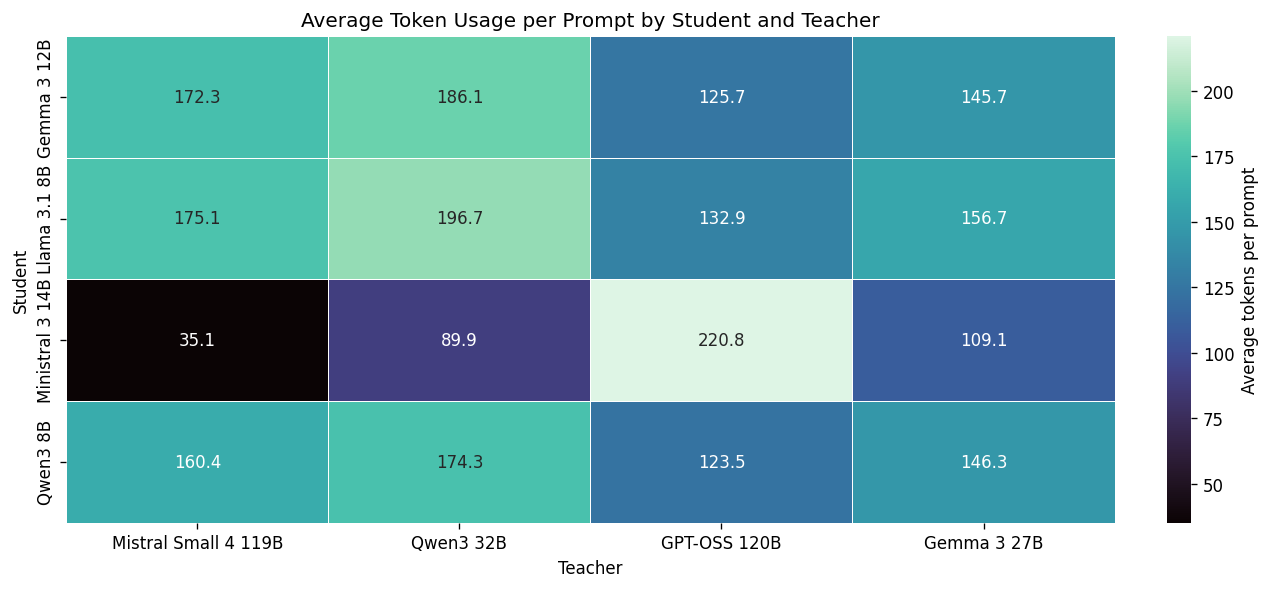


Tokens per second across students (averaged over teachers and intent conditions):


,student,tokens_per_second,total_tokens,total_elapsed_s
0,Gemma 3 12B,4711.4,12331112,2617.3
1,Llama 3.1 8B,6946.6,12951929,1864.5
2,Ministral 3 14B,3592.7,8908049,2479.5
3,Qwen3 8B,6215.1,11837115,1904.6


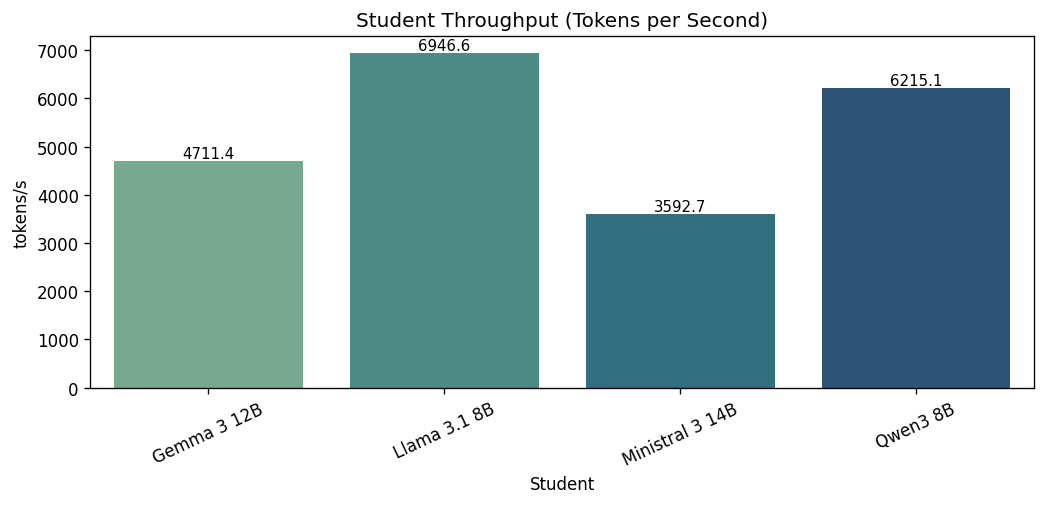


Condition-level token usage (tokens/prompt and tokens/s):


,teacher,student,condition,total_tokens,total_rows,total_elapsed_s,avg_tokens_per_prompt,avg_tokens_per_second
26,GPT-OSS 120B,Gemma 3 12B,Human Intent,1608127,11049,373.8,145.5,4302.5
24,GPT-OSS 120B,Gemma 3 12B,No Intent,nan,nan,nan,nan,nan
25,GPT-OSS 120B,Gemma 3 12B,Synthetic Intent,1575698,11049,480.8,142.6,3277.4
29,GPT-OSS 120B,Llama 3.1 8B,Human Intent,nan,nan,nan,nan,nan
27,GPT-OSS 120B,Llama 3.1 8B,No Intent,nan,nan,nan,nan,nan
28,GPT-OSS 120B,Llama 3.1 8B,Synthetic Intent,nan,nan,nan,nan,nan
32,GPT-OSS 120B,Ministral 3 14B,Human Intent,nan,nan,nan,nan,nan
30,GPT-OSS 120B,Ministral 3 14B,No Intent,nan,nan,nan,nan,nan
31,GPT-OSS 120B,Ministral 3 14B,Synthetic Intent,nan,nan,nan,nan,nan
35,GPT-OSS 120B,Qwen3 8B,Human Intent,nan,nan,nan,nan,nan


In [ ]:
# Token usage analysis: average tokens per prompt by student and teacher.

teacher_student_tokens = (
    combo_df.groupby(["teacher", "student"], as_index=False)
    .agg(
        total_tokens=("ood_val_total_tokens", "sum"),
        total_prompts=("ood_val_total_records", "sum"),
        total_elapsed_s=("ood_val_total_elapsed_s", "sum"),
    )
)
teacher_student_tokens["avg_tokens_per_prompt"] = np.where(
    teacher_student_tokens["total_prompts"] > 0,
    teacher_student_tokens["total_tokens"] / teacher_student_tokens["total_prompts"],
    np.nan,
)
teacher_student_tokens["avg_tokens_per_second"] = np.where(
    teacher_student_tokens["total_elapsed_s"] > 0,
    teacher_student_tokens["total_tokens"] / teacher_student_tokens["total_elapsed_s"],
    np.nan,
)

teacher_student_tokens = teacher_student_tokens.assign(
    teacher_rank=lambda df: df["teacher"].map({name: idx for idx, name in enumerate([TEACHERS[k] for k in TEACHER_ORDER])}),
    student_rank=lambda df: df["student"].map({name: idx for idx, name in enumerate([STUDENTS[k] for k in STUDENT_ORDER])}),
).sort_values(["teacher_rank", "student_rank"]).drop(columns=["teacher_rank", "student_rank"])

print("Average tokens per prompt across all datasets and both conditions:")
display(
    teacher_student_tokens.style.format(
        {
            "total_tokens": "{:.0f}",
            "total_prompts": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "avg_tokens_per_prompt": "{:.1f}",
            "avg_tokens_per_second": "{:.1f}",
        }
    )
)

# Student on rows (index), teacher on columns — student is the primary driver of token count.
pivot_tokens = teacher_student_tokens.pivot(index="student", columns="teacher", values="avg_tokens_per_prompt")
pivot_tokens = pivot_tokens.reindex(index=[STUDENTS[k] for k in STUDENT_ORDER], columns=[TEACHERS[k] for k in TEACHER_ORDER])

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
sns.heatmap(
    pivot_tokens,
    annot=True,
    fmt=".1f",
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Average tokens per prompt"},
    ax=ax,
)
ax.set_title("Average Token Usage per Prompt by Student and Teacher")
ax.set_xlabel("Teacher")
ax.set_ylabel("Student")
plt.show()

# Student-only throughput summary, averaged across all teachers and both intent conditions.
student_tps = (
    combo_df.groupby("student", as_index=False)
    .agg(total_tokens=("ood_val_total_tokens", "sum"), total_elapsed_s=("ood_val_total_elapsed_s", "sum"))
)
student_tps["tokens_per_second"] = np.where(
    student_tps["total_elapsed_s"] > 0,
    student_tps["total_tokens"] / student_tps["total_elapsed_s"],
    np.nan,
)
student_tps = student_tps.assign(
    student_rank=student_tps["student"].map({name: idx for idx, name in enumerate([STUDENTS[k] for k in STUDENT_ORDER])})
).sort_values("student_rank").drop(columns=["student_rank"])

print("\nTokens per second across students (averaged over teachers and intent conditions):")
display(
    student_tps[["student", "tokens_per_second", "total_tokens", "total_elapsed_s"]].style.format(
        {
            "tokens_per_second": "{:.1f}",
            "total_tokens": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.6, 4.1), constrained_layout=True)
colors = sns.color_palette("crest", n_colors=len(student_tps))
sns.barplot(
    data=student_tps,
    x="student",
    y="tokens_per_second",
    hue="student",
    palette=colors,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Student Throughput (Tokens per Second)")
ax.set_xlabel("Student")
ax.set_ylabel("tokens/s")
ax.tick_params(axis="x", rotation=25)
for bar, value in zip(ax.patches, student_tps["tokens_per_second"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1f}", ha="center", va="bottom", fontsize=9)
plt.show()

# Optional condition breakdown for the same normalization.
condition_tokens = combo_df[["teacher", "student", "condition", "total_tokens", "total_rows", "total_elapsed_s"]].copy()
condition_tokens["avg_tokens_per_prompt"] = np.where(
    condition_tokens["total_rows"] > 0,
    condition_tokens["total_tokens"] / condition_tokens["total_rows"],
    np.nan,
)
condition_tokens["avg_tokens_per_second"] = np.where(
    condition_tokens["total_elapsed_s"] > 0,
    condition_tokens["total_tokens"] / condition_tokens["total_elapsed_s"],
    np.nan,
)

print("\nCondition-level token usage (tokens/prompt and tokens/s):")
display(
    condition_tokens.sort_values(["teacher", "student", "condition"]).style.format(
        {
            "total_tokens": "{:.0f}",
            "total_rows": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "avg_tokens_per_prompt": "{:.1f}",
            "avg_tokens_per_second": "{:.1f}",
        }
    )
)

Condition comparison at the teacher/student level (OOD val F1):


condition_slug,teacher,student,no_intent,synthetic_intent,human_intent,synthetic_vs_no_intent,human_vs_synthetic_intent,human_vs_no_intent
12,GPT-OSS 120B,Gemma 3 12B,0.774,0.789,0.788,+0.015,-0.001,+0.014
13,GPT-OSS 120B,Llama 3.1 8B,0.772,0.787,0.781,+0.016,-0.006,+0.010
14,GPT-OSS 120B,Ministral 3 14B,0.591,0.556,0.640,-0.035,+0.084,+0.049
15,GPT-OSS 120B,Qwen3 8B,0.797,0.772,0.776,-0.025,+0.003,-0.021
4,Gemma 3 27B,Gemma 3 12B,0.764,0.721,0.749,-0.043,+0.028,-0.015
5,Gemma 3 27B,Llama 3.1 8B,0.775,0.741,0.767,-0.034,+0.026,-0.008
6,Gemma 3 27B,Ministral 3 14B,0.601,0.667,0.233,+0.066,-0.434,-0.368
7,Gemma 3 27B,Qwen3 8B,0.776,0.766,0.782,-0.009,+0.016,+0.007
8,Mistral Small 4 119B,Gemma 3 12B,0.775,0.775,0.767,+0.000,-0.008,-0.007
9,Mistral Small 4 119B,Llama 3.1 8B,0.755,0.780,0.780,+0.025,+0.000,+0.025


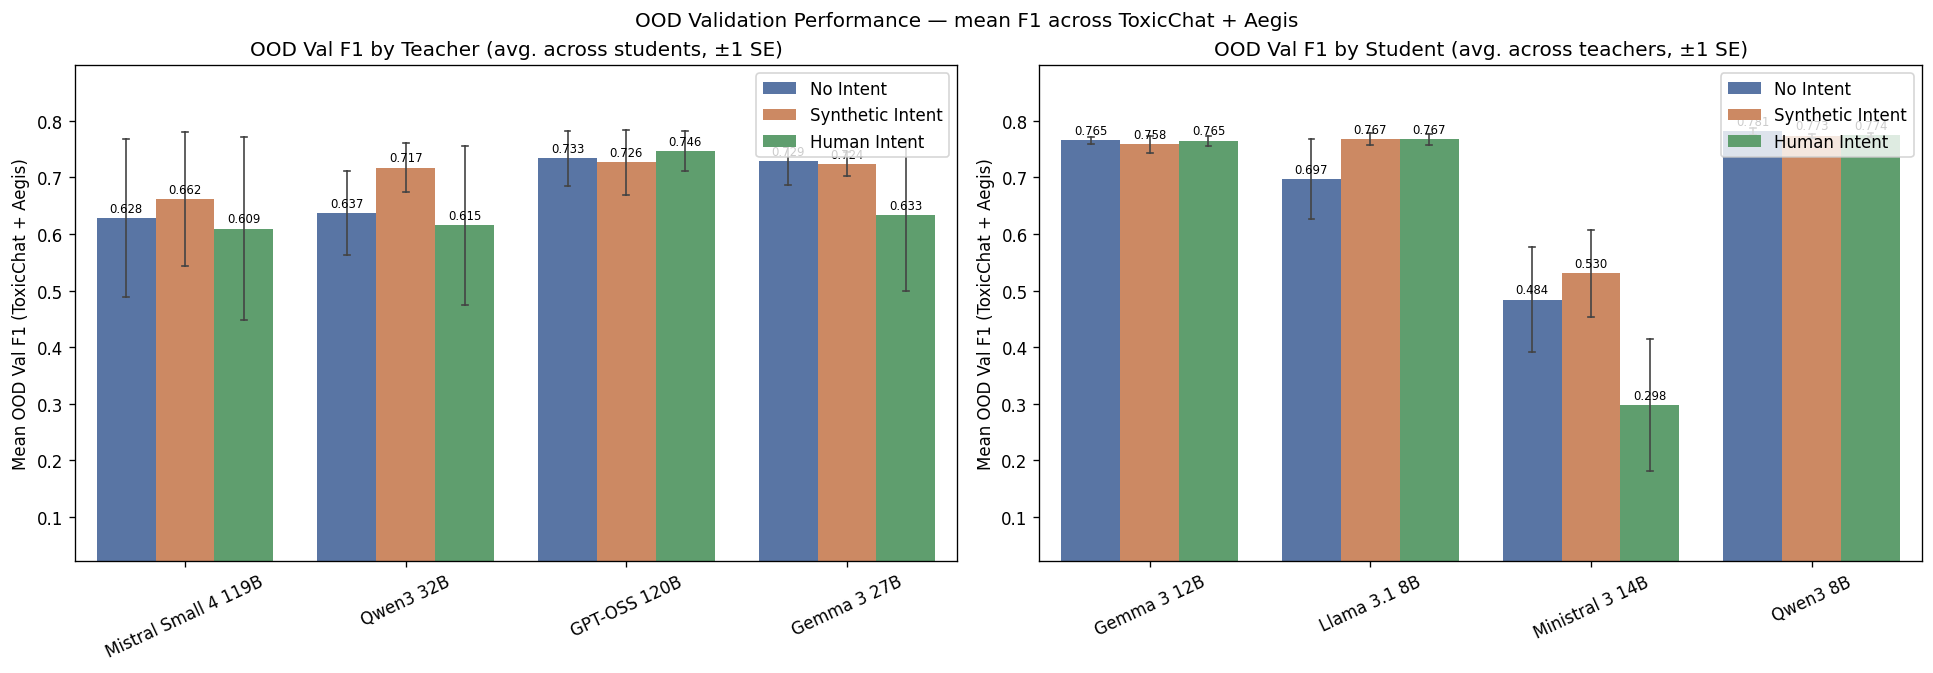

Summary of intent effect (OOD val F1, ToxicChat + Aegis):
  synthetic vs no intent — mean delta: +0.0255
  human vs no intent     — mean delta: -0.0309
  human vs synthetic     — mean delta: -0.0564
  Pairs where human > no intent: 7/16


In [ ]:
# Condition comparison on OOD validation: per-condition OOD val F1 by teacher and by student.
# Teachers plot averages across students; students plot averages across teachers.
condition_ood = (
    combo_df.pivot_table(
        index=["teacher_slug", "teacher", "student_slug", "student"],
        columns="condition_slug",
        values="ood_val_harm_f1",
        aggfunc="mean",
    )
    .reset_index()
)

condition_ood["synthetic_vs_no_intent"]    = condition_ood["synthetic_intent"] - condition_ood["no_intent"]
condition_ood["human_vs_synthetic_intent"] = condition_ood["human_intent"]    - condition_ood["synthetic_intent"]
condition_ood["human_vs_no_intent"]        = condition_ood["human_intent"]    - condition_ood["no_intent"]

pairwise_display = condition_ood[[
    "teacher", "student",
    "no_intent", "synthetic_intent", "human_intent",
    "synthetic_vs_no_intent", "human_vs_synthetic_intent", "human_vs_no_intent",
]].copy()

print("Condition comparison at the teacher/student level (OOD val F1):")
display(
    pairwise_display.sort_values(["teacher", "student"]).style.format({
        "no_intent": "{:.3f}",
        "synthetic_intent": "{:.3f}",
        "human_intent": "{:.3f}",
        "synthetic_vs_no_intent": "{:+.3f}",
        "human_vs_synthetic_intent": "{:+.3f}",
        "human_vs_no_intent": "{:+.3f}",
    })
)

# ── Long-form aggregations ────────────────────────────────────────────────────
CONDITION_LABEL_MAP = {
    "no_intent": "No Intent",
    "synthetic_intent": "Synthetic Intent",
    "human_intent": "Human Intent",
}
CONDITION_LABEL_ORDER = ["No Intent", "Synthetic Intent", "Human Intent"]
CONDITION_PALETTE = dict(zip(CONDITION_LABEL_ORDER, sns.color_palette("deep", 3)))


# Long-form rows: one per (teacher, student, condition) — keeps variance for error bars.
ood_long = condition_ood.melt(
    id_vars=["teacher_slug", "teacher", "student_slug", "student"],
    value_vars=["no_intent", "synthetic_intent", "human_intent"],
    var_name="condition_slug",
    value_name="ood_val_harm_f1",
).dropna(subset=["ood_val_harm_f1"])
ood_long["condition"] = ood_long["condition_slug"].map(CONDITION_LABEL_MAP)


def _ylim(df, col):
    lo, hi = df[col].min(), df[col].max()
    pad = (hi - lo) * 0.15 if hi > lo else 0.05
    return max(0.0, lo - pad), min(1.0, hi + pad)


fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)

from matplotlib.container import BarContainer

for ax, label_col, order_slugs, slug_to_name, other_dim in [
    (axes[0], "teacher", TEACHER_ORDER, TEACHERS, "students"),
    (axes[1], "student", STUDENT_ORDER, STUDENTS, "teachers"),
]:
    x_order = [slug_to_name[s] for s in order_slugs if slug_to_name.get(s) in ood_long[label_col].values]
    sns.barplot(
        data=ood_long,
        x=label_col,
        y="ood_val_harm_f1",
        hue="condition",
        hue_order=CONDITION_LABEL_ORDER,
        order=x_order,
        palette=CONDITION_PALETTE,
        ax=ax,
        errorbar="se",
        capsize=0.08,
        err_kws={"linewidth": 1.0, "color": "#444"},
    )
    ax.set_title(f"OOD Val F1 by {label_col.title()} (avg. across {other_dim}, ±1 SE)")
    ax.set_ylabel("Mean OOD Val F1 (ToxicChat + Aegis)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(*_ylim(ood_long, "ood_val_harm_f1"))
    # Only label actual bars (BarContainer); skip ErrorbarContainer.
    for container in ax.containers:
        if isinstance(container, BarContainer):
            ax.bar_label(
                container,
                labels=[f"{bar.get_height():.3f}" for bar in container],
                padding=2,
                fontsize=7,
            )
    ax.legend(title=None, loc="upper right")

fig.suptitle("OOD Validation Performance — mean F1 across ToxicChat + Aegis", fontsize=12)
plt.show()

print("Summary of intent effect (OOD val F1, ToxicChat + Aegis):")
print(f"  synthetic vs no intent — mean delta: {condition_ood['synthetic_vs_no_intent'].mean():+.4f}")
print(f"  human vs no intent     — mean delta: {condition_ood['human_vs_no_intent'].mean():+.4f}")
print(f"  human vs synthetic     — mean delta: {condition_ood['human_vs_synthetic_intent'].mean():+.4f}")
print(f"  Pairs where human > no intent: {(condition_ood['human_vs_no_intent'] > 0).sum()}/{len(condition_ood)}")


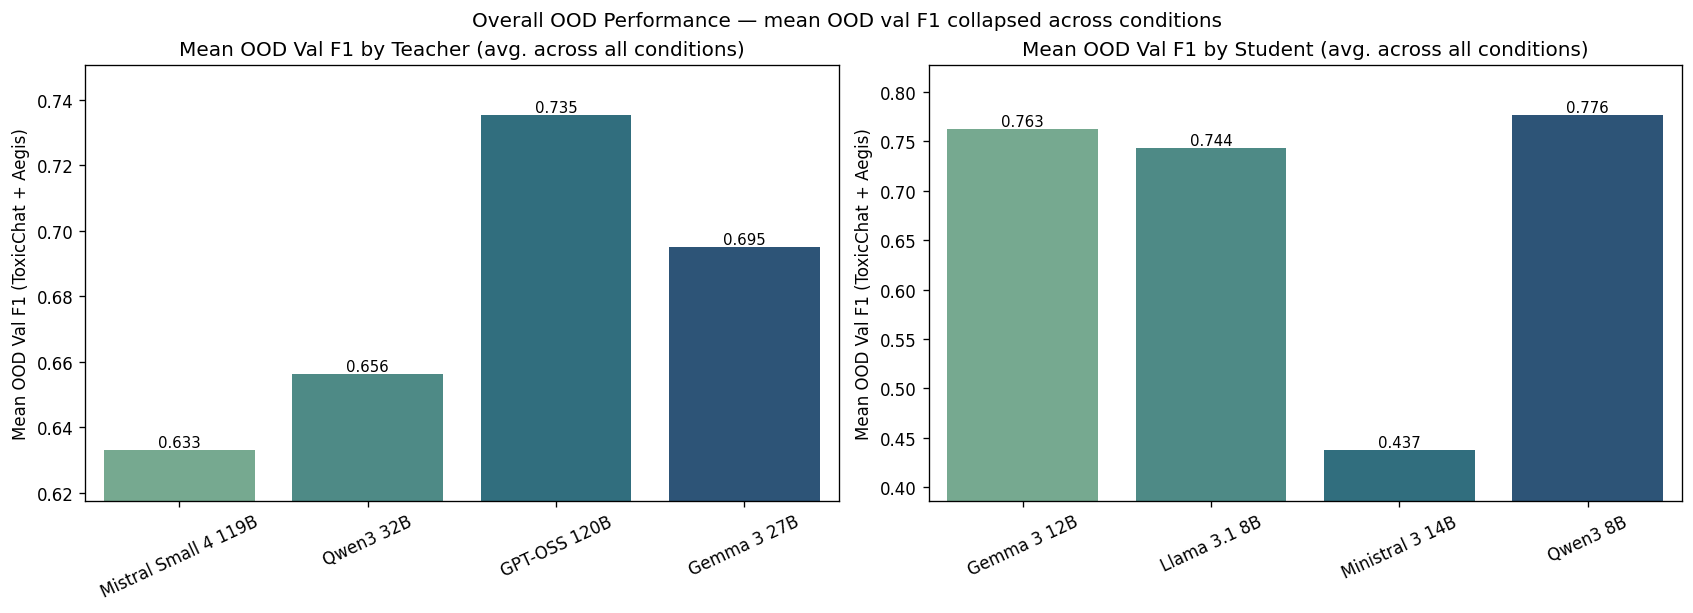

Mean OOD val F1 by teacher (across all conditions and students):


,teacher,ood_val_harm_f1
2,Mistral Small 4 119B,0.633
0,Qwen3 32B,0.656
3,GPT-OSS 120B,0.735
1,Gemma 3 27B,0.695



Mean OOD val F1 by student (across all conditions and teachers):


,student,ood_val_harm_f1
0,Gemma 3 12B,0.763
1,Llama 3.1 8B,0.744
2,Ministral 3 14B,0.437
3,Qwen3 8B,0.776


In [ ]:
# Mean OOD val F1 by teacher and by student, averaged across all 3 conditions.
# Complements the condition-breakdown plots above by showing the overall ranking
# of each teacher/student regardless of which condition was used.

val_by_teacher = (
    combo_df.groupby(["teacher_slug", "teacher"], as_index=False)["ood_val_harm_f1"]
    .mean()
    .assign(teacher_rank=lambda df: df["teacher_slug"].map({s: i for i, s in enumerate(TEACHER_ORDER)}))
    .sort_values("teacher_rank")
    .drop(columns="teacher_rank")
)

val_by_student = (
    combo_df.groupby(["student_slug", "student"], as_index=False)["ood_val_harm_f1"]
    .mean()
    .assign(student_rank=lambda df: df["student_slug"].map({s: i for i, s in enumerate(STUDENT_ORDER)}))
    .sort_values("student_rank")
    .drop(columns="student_rank")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, df, label_col, slug_col, order in [
    (axes[0], val_by_teacher, "teacher", "teacher_slug", TEACHER_ORDER),
    (axes[1], val_by_student, "student", "student_slug", STUDENT_ORDER),
]:
    x_order = [TEACHERS[s] if label_col == "teacher" else STUDENTS[s] for s in order if s in df[slug_col].values]
    colors = sns.color_palette("crest", n_colors=len(x_order))
    sns.barplot(
        data=df,
        x=label_col,
        y="ood_val_harm_f1",
        order=x_order,
        palette=colors,
        hue=label_col,
        legend=False,
        ax=ax,
        errorbar=None,
    )
    ax.set_title(f"Mean OOD Val F1 by {label_col.title()} (avg. across all conditions)")
    ax.set_ylabel("Mean OOD Val F1 (ToxicChat + Aegis)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    lo = df["ood_val_harm_f1"].min()
    hi = df["ood_val_harm_f1"].max()
    pad = (hi - lo) * 0.15 if hi > lo else 0.05
    ax.set_ylim(max(0.0, lo - pad), min(1.0, hi + pad))
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9,
        )

fig.suptitle("Overall OOD Performance — mean OOD val F1 collapsed across conditions", fontsize=12)
plt.show()

print("Mean OOD val F1 by teacher (across all conditions and students):")
display(val_by_teacher[["teacher", "ood_val_harm_f1"]].style.format({"ood_val_harm_f1": "{:.3f}"}))
print("\nMean OOD val F1 by student (across all conditions and teachers):")
display(val_by_student[["student", "ood_val_harm_f1"]].style.format({"ood_val_harm_f1": "{:.3f}"}))

condition_slug,dataset,no_intent,synthetic_intent,human_intent,synthetic_vs_no_intent,human_vs_synthetic_intent,human_vs_no_intent
1,Toxic Chat,0.610,0.628,0.592,+0.018,-0.036,-0.018
0,Aegis,0.754,0.786,0.710,+0.033,-0.076,-0.044


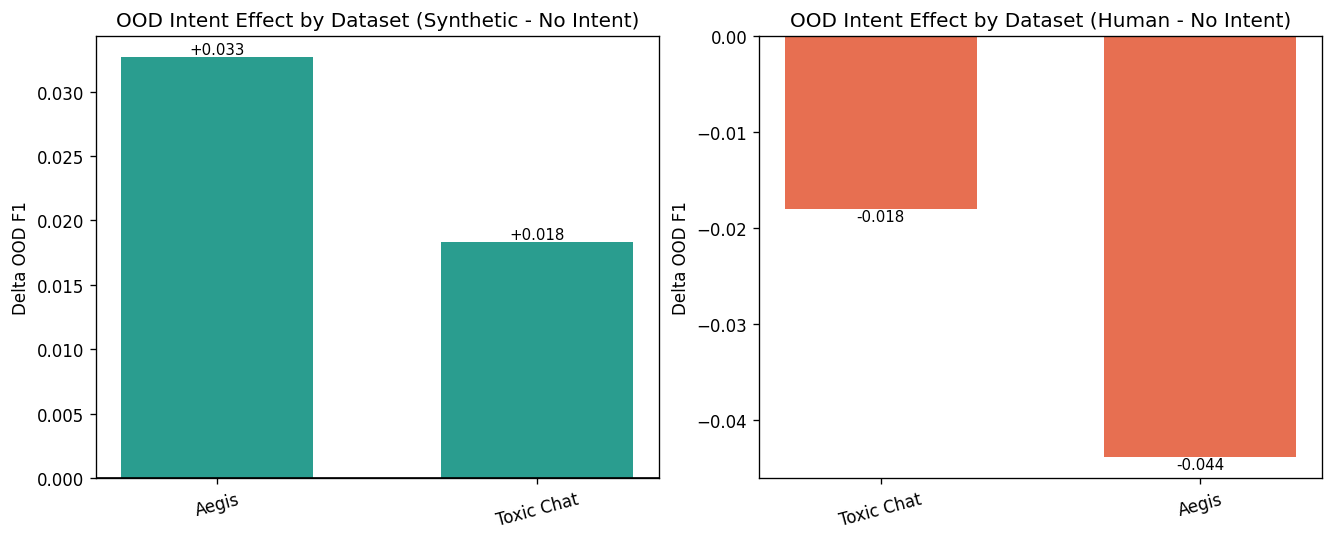

OOD intent effect summary:
  synthetic vs no intent — mean delta: +0.0255, datasets positive: 2/2
  human vs no intent — mean delta: -0.0309, datasets positive: 0/2


In [ ]:
# Intent impact on the OOD validation datasets (ToxicChat, Aegis).
# For each (dataset, condition), F1 is averaged across all (teacher × student) pairs;
# the per-condition deltas highlight whether adding intent improves OOD generalisation.

dataset_ood = (
    ood_val_df.pivot_table(
        index=["dataset_slug", "dataset"],
        columns="condition_slug",
        values="f1",
        aggfunc="mean",
    )
    .reset_index()
)

for cond in ["no_intent", "synthetic_intent", "human_intent"]:
    if cond not in dataset_ood.columns:
        dataset_ood[cond] = np.nan

dataset_ood["synthetic_vs_no_intent"]    = dataset_ood["synthetic_intent"] - dataset_ood["no_intent"]
dataset_ood["human_vs_synthetic_intent"] = dataset_ood["human_intent"]    - dataset_ood["synthetic_intent"]
dataset_ood["human_vs_no_intent"]        = dataset_ood["human_intent"]    - dataset_ood["no_intent"]

dataset_display = dataset_ood[[
    "dataset",
    "no_intent", "synthetic_intent", "human_intent",
    "synthetic_vs_no_intent", "human_vs_synthetic_intent", "human_vs_no_intent",
]].copy()

dataset_display = dataset_display.sort_values("human_vs_no_intent", ascending=False)

display(
    dataset_display.style.format({
        "no_intent": "{:.3f}",
        "synthetic_intent": "{:.3f}",
        "human_intent": "{:.3f}",
        "synthetic_vs_no_intent": "{:+.3f}",
        "human_vs_synthetic_intent": "{:+.3f}",
        "human_vs_no_intent": "{:+.3f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)

for ax, delta_col, title, ylabel in [
    (axes[0], "synthetic_vs_no_intent", "OOD Intent Effect by Dataset (Synthetic - No Intent)", "Delta OOD F1"),
    (axes[1], "human_vs_no_intent",     "OOD Intent Effect by Dataset (Human - No Intent)",     "Delta OOD F1"),
]:
    sorted_df = dataset_display.sort_values(delta_col, ascending=False)
    colors = ["#2A9D8F" if v >= 0 else "#E76F51" for v in sorted_df[delta_col]]
    ax.bar(sorted_df["dataset"], sorted_df[delta_col], color=colors, width=0.6)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)
    for x_pos, value in enumerate(sorted_df[delta_col]):
        ax.text(x_pos, value, f"{value:+.3f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)

plt.show()

print("OOD intent effect summary:")
for label, col in [("synthetic vs no intent", "synthetic_vs_no_intent"), ("human vs no intent", "human_vs_no_intent")]:
    print(f"  {label} — mean delta: {dataset_ood[col].mean():+.4f}, datasets positive: {(dataset_ood[col] > 0).sum()}/{len(dataset_ood)}")


Marginal-selected combo: GPT-OSS 120B / Qwen3 8B / Human Intent  (ood_f1 of cell=0.776)
  teacher_marg=0.7353, student_marg=0.7761, cond_blend=0.7601


,WildGuard
Average,0.804
Aegis,0.809
OpenAI Moderation,0.724
Toxic Chat,0.652
WildGuardMix,0.888
XSTest,0.945


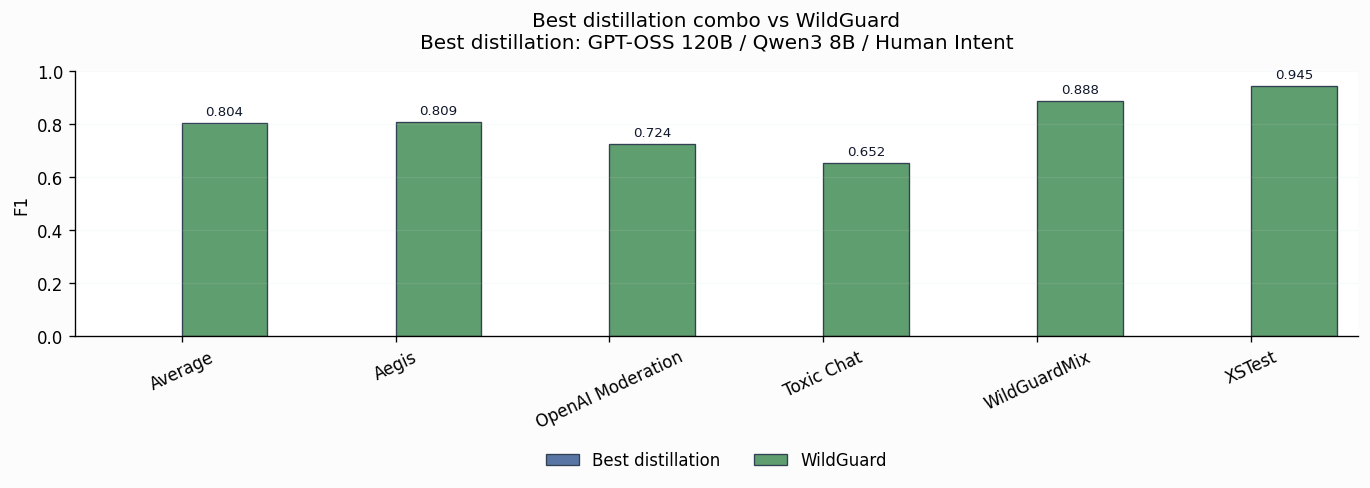

Best combo selected: teacher=GPT-OSS 120B, student=Qwen3 8B, condition=Human Intent, ood_val_f1=0.7759
Distillation average across datasets: nan
WildGuard average across datasets: 0.8038


In [ ]:
# Best overall result: compare the top distillation combo against WildGuard across datasets.

def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def compute_metrics(results: list[dict]) -> dict:
    tp = fp = tn = fn = 0
    for record in results:
        true_harm = record.get("true_harm_binary") or record.get("true_harm")
        pred_harm = record.get("predicted_harm")
        if true_harm is None or pred_harm is None:
            continue
        true_lower = str(true_harm).lower()
        pred_lower = str(pred_harm).lower()
        if true_lower == "harmful" and pred_lower == "harmful":
            tp += 1
        elif true_lower == "safe" and pred_lower == "harmful":
            fp += 1
        elif true_lower == "safe" and pred_lower == "safe":
            tn += 1
        elif true_lower == "harmful" and pred_lower == "safe":
            fn += 1
    total = tp + fp + tn + fn
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"accuracy": (tp + tn) / total if total else 0.0, "precision": precision, "recall": recall, "f1": f1}


# Marginal-based selection — mirrors submit_distillation_eval.py --mode test:
#   1. Teacher with highest mean OOD F1 across (student × condition).
#   2. Student with highest mean OOD F1 across (teacher × condition).
#   3. Condition that maximises mean(teacher_marg_for_cond, student_marg_for_cond).
_scored = combo_df.dropna(subset=["ood_val_harm_f1"])
if _scored.empty:
    raise RuntimeError("No combinations have OOD val F1 — run submit_distillation_eval.py --mode ood-val first.")
_teacher_means = _scored.groupby("teacher_slug")["ood_val_harm_f1"].mean()
_student_means = _scored.groupby("student_slug")["ood_val_harm_f1"].mean()
best_teacher_slug = _teacher_means.idxmax()
best_student_slug = _student_means.idxmax()
_teacher_cond_marg = _scored[_scored["teacher_slug"] == best_teacher_slug].groupby("condition_slug")["ood_val_harm_f1"].mean()
_student_cond_marg = _scored[_scored["student_slug"] == best_student_slug].groupby("condition_slug")["ood_val_harm_f1"].mean()
_cond_blend = ((_teacher_cond_marg + _student_cond_marg) / 2).dropna()
best_condition_slug = _cond_blend.idxmax()

_match = combo_df[
    (combo_df["teacher_slug"]   == best_teacher_slug)
    & (combo_df["student_slug"] == best_student_slug)
    & (combo_df["condition_slug"] == best_condition_slug)
]
if _match.empty:
    raise RuntimeError(
        f"No combo_df row for selected pair "
        f"{best_teacher_slug}/{best_student_slug}/{best_condition_slug}"
    )
best_combo = _match.iloc[0]

best_teacher = best_combo["teacher"]
best_student = best_combo["student"]
best_condition = best_combo["condition"]
best_ood_f1 = float(best_combo["ood_val_harm_f1"])

print(f"Marginal-selected combo: {best_teacher} / {best_student} / {best_condition}  (ood_f1 of cell={best_ood_f1:.3f})")
print(f"  teacher_marg={_teacher_means[best_teacher_slug]:.4f}, student_marg={_student_means[best_student_slug]:.4f}, "
      f"cond_blend={_cond_blend[best_condition_slug]:.4f}")

best_records = records_df[
    (records_df["teacher"] == best_teacher)
    & (records_df["student"] == best_student)
    & (records_df["condition"] == best_condition)
].copy()

best_summary = (
    best_records.groupby("dataset", as_index=False)["f1"]
    .mean()
    .rename(columns={"dataset": "dataset", "f1": "f1"})
    .query("dataset != 'Annotated Intents'")
    .sort_values("dataset")
    .reset_index(drop=True)
)

safety_results_root = PROJECT_ROOT / "data/safety_experiment"
wildguard_paths = {
    "Aegis": safety_results_root / "aegis" / "allenai_wildguard_wildguard_classification.jsonl",
    "OpenAI Moderation": safety_results_root / "openai-moderation" / "allenai_wildguard_wildguard_classification.jsonl",
    "Toxic Chat": safety_results_root / "toxic-chat" / "allenai_wildguard_wildguard_classification.jsonl",
    "WildGuardMix": safety_results_root / "wildguardmix" / "allenai_wildguard_wildguard_classification.jsonl",
    "XSTest": safety_results_root / "xstest" / "allenai_wildguard_wildguard_classification.jsonl",
}

wildguard_rows = []
for dataset, path in wildguard_paths.items():
    wildguard_rows.append({"dataset": dataset, "model": "WildGuard", **compute_metrics(load_jsonl(path))})

wildguard_summary = pd.DataFrame(wildguard_rows)[["dataset", "model", "f1"]]

comparison_df = pd.concat(
    [
        best_summary.assign(model="Best distillation"),
        wildguard_summary,
    ],
    ignore_index=True,
 )

average_df = comparison_df.groupby("model", as_index=False)["f1"].mean().assign(dataset="Average")
comparison_df = pd.concat([comparison_df, average_df], ignore_index=True)

dataset_order = ["Average"] + sorted(d for d in comparison_df["dataset"].unique() if d != "Average")
model_order = ["Best distillation", "WildGuard"]
comparison_df["dataset"] = pd.Categorical(comparison_df["dataset"], categories=dataset_order, ordered=True)
comparison_df["model"] = pd.Categorical(comparison_df["model"], categories=model_order, ordered=True)
comparison_df = comparison_df.sort_values(["dataset", "model"]).reset_index(drop=True)

display(comparison_df.pivot(index="dataset", columns="model", values="f1").reindex(dataset_order).rename_axis(index=None, columns=None).style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(13.8, 5.8))
fig.patch.set_facecolor("#fcfcfc")
ax.set_facecolor("white")
palette = {"Best distillation": sns.color_palette("deep")[0], "WildGuard": sns.color_palette("deep")[2]}

sns.barplot(
    data=comparison_df,
    x="dataset",
    y="f1",
    hue="model",
    order=dataset_order,
    hue_order=model_order,
    palette=palette,
    ax=ax,
    edgecolor="#334155",
    linewidth=0.8,
    errorbar=None,
)

ax.set_title(
    f"Best distillation combo vs WildGuard\n"
    f"Best distillation: {best_teacher} / {best_student} / {best_condition}",
    pad=14,
)
ax.set_xlabel("")
ax.xaxis.label.set_visible(False)
ax.set_ylabel("F1")
ax.set_ylim(0, min(1.0, max(comparison_df["f1"].max() * 1.12, 0.05)))
ax.tick_params(axis="x", rotation=25, labelsize=10)
ax.grid(axis="y", color="#cbd5e1", alpha=0.12, linewidth=0.8)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_height():.3f}" for bar in container], padding=3, fontsize=8, color="#0f172a")

ax.legend(title=None, loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2, frameon=False)
sns.despine(ax=ax, left=False, bottom=False)
fig.subplots_adjust(bottom=0.50)
plt.show()

print(f"Best combo selected: teacher={best_teacher}, student={best_student}, condition={best_condition}, ood_val_f1={best_ood_f1:.4f}")
print(f"Distillation average across datasets: {comparison_df[comparison_df['model'] == 'Best distillation']['f1'].mean():.4f}")
print(f"WildGuard average across datasets: {comparison_df[comparison_df['model'] == 'WildGuard']['f1'].mean():.4f}")

In [ ]:
# Efficiency comparison: WildGuard baseline vs best distillation combo

api = wandb.Api()


def _dataset_aliases(slug: str) -> set[str]:
    aliases = {slug, slug.replace("-", "_")}
    if slug == "annotated-intents":
        aliases.add("annotated_intents")
    if slug == "toxic-chat":
        aliases.add("toxic_chat")
    return aliases


def _extract_dataset_condition_metrics(summary: dict) -> pd.DataFrame:
    rows = []
    patterns = [
        re.compile(r"^([^/]+)/([^/]+)/total_tokens$"),
        re.compile(r"^([^/]+)/([^/]+)/elapsed_s$"),
        re.compile(r"^([^/]+)/([^/]+)/total$"),
    ]

    grouped = {}
    for key, value in summary.items():
        if not isinstance(key, str):
            continue
        for pattern in patterns:
            match = pattern.match(key)
            if not match:
                continue
            dataset_raw, condition = match.group(1), match.group(2)
            metric_name = key.rsplit("/", 1)[-1]
            grouped.setdefault((dataset_raw, condition), {})[metric_name] = value
            break

    canonical = {}
    alias_to_canonical = {}
    for dataset_slug in DATASETS.keys():
        for alias in _dataset_aliases(dataset_slug):
            alias_to_canonical[alias] = dataset_slug

    for (dataset_raw, condition), metrics in grouped.items():
        dataset_slug = alias_to_canonical.get(dataset_raw)
        if dataset_slug is None:
            continue
        canonical.setdefault((dataset_slug, condition), {}).update(metrics)

    for (dataset_slug, condition), metrics in canonical.items():
        rows.append(
            {
                "dataset_slug": dataset_slug,
                "condition": condition,
                "total_tokens": pd.to_numeric(metrics.get("total_tokens"), errors="coerce"),
                "elapsed_s": pd.to_numeric(metrics.get("elapsed_s"), errors="coerce"),
                "total_prompts": pd.to_numeric(metrics.get("total"), errors="coerce"),
            }
        )

    return pd.DataFrame(rows)


def _get_wildguard_summary_from_artifact() -> tuple[dict, str]:
    artifact_candidates = [
        "intention-analysis/Baselines/safety-experiment-baselines:latest",
        "Jazhyc/Baselines/safety-experiment-baselines:latest",
    ]

    for artifact_ref in artifact_candidates:
        try:
            artifact = api.artifact(artifact_ref)
            run = artifact.logged_by()
            if run is not None:
                return dict(run.summary), f"artifact:{artifact_ref} (run={run.id})"
        except Exception:
            continue

    run_candidates = [
        "intention-analysis/Baselines",
        "Jazhyc/Baselines",
    ]
    for path in run_candidates:
        try:
            runs = api.runs(path=path, per_page=200)
        except Exception:
            continue

        for run in runs:
            summary = dict(run.summary)
            has_tokens = any(isinstance(k, str) and k.endswith("/total_tokens") for k in summary.keys())
            has_wildguard = (
                "wildguard" in (getattr(run, "display_name", "") or "").lower()
                or "wildguard" in (getattr(run, "name", "") or "").lower()
                or any("wildguard" in str(k).lower() for k in summary.keys())
            )
            if has_tokens and has_wildguard:
                return summary, f"run:{path}/{run.id}"

    raise RuntimeError("Could not locate WildGuard baseline summary in artifacts or Baselines runs.")


# 1) Best distillation aggregate via marginal selection — mirrors
# submit_distillation_eval.py --mode test:
#   a) teacher with highest mean OOD F1 across (student × condition)
#   b) student with highest mean OOD F1 across (teacher × condition)
#   c) condition that maximises mean(teacher_marg_for_cond, student_marg_for_cond)
_scored = combo_df.dropna(subset=["ood_val_harm_f1"])
_teacher_means = _scored.groupby("teacher_slug")["ood_val_harm_f1"].mean()
_student_means = _scored.groupby("student_slug")["ood_val_harm_f1"].mean()
_best_teacher_slug = _teacher_means.idxmax()
_best_student_slug = _student_means.idxmax()
_teacher_cond_marg = _scored[_scored["teacher_slug"] == _best_teacher_slug].groupby("condition_slug")["ood_val_harm_f1"].mean()
_student_cond_marg = _scored[_scored["student_slug"] == _best_student_slug].groupby("condition_slug")["ood_val_harm_f1"].mean()
_cond_blend = ((_teacher_cond_marg + _student_cond_marg) / 2).dropna()
_best_condition_slug = _cond_blend.idxmax()

_match = combo_df[
    (combo_df["teacher_slug"]   == _best_teacher_slug)
    & (combo_df["student_slug"] == _best_student_slug)
    & (combo_df["condition_slug"] == _best_condition_slug)
]
if _match.empty:
    raise RuntimeError(
        f"No combo_df row for selected pair "
        f"{_best_teacher_slug}/{_best_student_slug}/{_best_condition_slug}"
    )
best_combo_row = _match.iloc[0]
best_teacher_name = best_combo_row["teacher"]
best_student_name = best_combo_row["student"]
best_condition_name = best_combo_row["condition"]
print(f"Marginal selection: {best_teacher_name} / {best_student_name} / {best_condition_name}")
print(f"  teacher_marg={_teacher_means[_best_teacher_slug]:.4f}, student_marg={_student_means[_best_student_slug]:.4f}, "
      f"cond_blend={_cond_blend[_best_condition_slug]:.4f}")

best_records_eff = records_df[
    (records_df["teacher"] == best_teacher_name)
    & (records_df["student"] == best_student_name)
    & (records_df["condition"] == best_condition_name)
].copy()

# 2) WildGuard metrics from WandB artifact/run summary
wildguard_summary, wildguard_source = _get_wildguard_summary_from_artifact()
wildguard_metrics = _extract_dataset_condition_metrics(wildguard_summary)

if wildguard_metrics.empty:
    raise RuntimeError("Found WildGuard summary source but no dataset-level token/elapsed metrics were parseable.")

# Prefer a condition containing 'wildguard'; otherwise use condition with max dataset coverage.
coverage = (
    wildguard_metrics.groupby("condition", as_index=False)
    .agg(datasets=("dataset_slug", "nunique"))
    .sort_values(["datasets", "condition"], ascending=[False, True])
)
preferred = coverage[coverage["condition"].str.contains("wildguard", case=False, regex=False)]
if not preferred.empty:
    wildguard_condition = preferred.iloc[0]["condition"]
else:
    wildguard_condition = coverage.iloc[0]["condition"]

wildguard_selected = wildguard_metrics[wildguard_metrics["condition"] == wildguard_condition].copy()

# Compare on overlapping datasets for fairness.
common_datasets = sorted(set(best_records_eff["dataset_slug"]).intersection(set(wildguard_selected["dataset_slug"])))
if not common_datasets:
    raise RuntimeError("No overlapping datasets found between best distillation records and WildGuard summary metrics.")

best_overlap = best_records_eff[best_records_eff["dataset_slug"].isin(common_datasets)].copy()
wildguard_overlap = wildguard_selected[wildguard_selected["dataset_slug"].isin(common_datasets)].copy()

best_total_tokens = pd.to_numeric(best_overlap["total_tokens"], errors="coerce").sum()
best_total_elapsed = pd.to_numeric(best_overlap["wandb_elapsed_s"], errors="coerce").sum()
best_total_elapsed = best_total_elapsed if best_total_elapsed > 0 else float("nan")
best_total_prompts = pd.to_numeric(best_overlap["num_rows"], errors="coerce").sum()

wg_total_tokens = pd.to_numeric(wildguard_overlap["total_tokens"], errors="coerce").sum()
wg_total_elapsed = pd.to_numeric(wildguard_overlap["elapsed_s"], errors="coerce").sum()
wg_total_prompts = pd.to_numeric(wildguard_overlap["total_prompts"], errors="coerce").sum()

comparison_efficiency = pd.DataFrame(
    [
        {
            "model": "Best distillation",
            "details": f"{best_teacher_name} / {best_student_name} / {best_condition_name}",
            "datasets_compared": len(common_datasets),
            "total_prompts": best_total_prompts,
            "total_tokens": best_total_tokens,
            "total_elapsed_s": best_total_elapsed,
        },
        {
            "model": "WildGuard",
            "details": f"condition={wildguard_condition}",
            "datasets_compared": len(common_datasets),
            "total_prompts": wg_total_prompts,
            "total_tokens": wg_total_tokens,
            "total_elapsed_s": wg_total_elapsed,
        },
    ]
)

comparison_efficiency["tokens_per_prompt"] = comparison_efficiency["total_tokens"] / comparison_efficiency["total_prompts"]
comparison_efficiency["seconds_per_prompt"] = comparison_efficiency["total_elapsed_s"] / comparison_efficiency["total_prompts"]
comparison_efficiency["tokens_per_second"] = comparison_efficiency["total_tokens"] / comparison_efficiency["total_elapsed_s"]

print("Efficiency comparison on overlapping datasets:", ", ".join(common_datasets))
print("WildGuard metrics source:", wildguard_source)

display(
    comparison_efficiency.style.format(
        {
            "datasets_compared": "{:.0f}",
            "total_prompts": "{:.0f}",
            "total_tokens": "{:.0f}",
            "total_elapsed_s": "{:.1f}",
            "tokens_per_prompt": "{:.1f}",
            "seconds_per_prompt": "{:.4f}",
            "tokens_per_second": "{:.1f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4), constrained_layout=True)
sns.barplot(data=comparison_efficiency, x="model", y="tokens_per_prompt", hue="model", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Tokens per Prompt")
axes[0].set_ylabel("tokens/prompt")
axes[0].set_xlabel("")

sns.barplot(data=comparison_efficiency, x="model", y="seconds_per_prompt", hue="model", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Seconds per Prompt")
axes[1].set_ylabel("seconds/prompt")
axes[1].set_xlabel("")

for ax in axes:
    for bar in ax.patches:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

plt.show()

Marginal selection: GPT-OSS 120B / Qwen3 8B / Human Intent
  teacher_marg=0.7353, student_marg=0.7761, cond_blend=0.7601


RuntimeError: No overlapping datasets found between best distillation records and WildGuard summary metrics.

In [ ]:
# ── Post-hoc analysis: average test F1 across held-out benchmarks ────────────
#
# Exploratory purposes
#
# This cell is useful for understanding *why* a val-selected model generalises
# (or fails to), and for checking whether the val criterion is a reliable proxy
# for broader benchmark performance.
#
# annotated-intents is excluded from the average below because its validation
# split was used for adapter selection — including the test split would mix
# selection and evaluation distributions.

HELD_OUT_DATASETS = [ds for ds in DATASETS if ds != "annotated-intents"]

held_out_f1 = (
    records_df[records_df["dataset_slug"].isin(HELD_OUT_DATASETS)]
    .groupby(
        ["teacher_slug", "teacher", "student_slug", "student", "condition_slug", "condition"],
        as_index=False,
    )
    .agg(mean_test_f1=("f1", "mean"), datasets_scored=("dataset_slug", "nunique"))
    .merge(
        combo_df[["teacher_slug", "student_slug", "condition_slug", "ood_val_harm_f1"]],
        on=["teacher_slug", "student_slug", "condition_slug"],
        how="left",
    )
    .sort_values("mean_test_f1", ascending=False)
    .reset_index(drop=True)
)

val_best_idx  = held_out_f1["ood_val_harm_f1"].idxmax()
test_best_idx = held_out_f1["mean_test_f1"].idxmax()
val_best  = held_out_f1.loc[val_best_idx]
test_best = held_out_f1.loc[test_best_idx]

rank_df = held_out_f1[
    ["teacher", "student", "condition", "datasets_scored", "mean_test_f1", "ood_val_harm_f1"]
].copy()
rank_df.index = range(1, len(rank_df) + 1)
rank_df.index.name = "rank"

n_held_out = int(held_out_f1["datasets_scored"].max())
print(f"Ranked by mean test F1 across {n_held_out} held-out datasets ({', '.join(HELD_OUT_DATASETS)}):")
display(
    rank_df.style.format({"mean_test_f1": "{:.3f}", "ood_val_harm_f1": "{:.3f}"})
    .highlight_max(subset=["mean_test_f1"], color="#d4edda")
    .highlight_max(subset=["ood_val_harm_f1"], color="#cce5ff")
)

print(
    f"\nBest by ood_val_harm_f1 (held-out selection):"
    f"\n  {val_best['teacher']} / {val_best['student']} / {val_best['condition']}"
    f"  (val={val_best['ood_val_harm_f1']:.3f}, mean_test_f1={val_best['mean_test_f1']:.3f})"
)
print(
    f"\nBest by mean_test_f1 (post-hoc, for reference only):"
    f"\n  {test_best['teacher']} / {test_best['student']} / {test_best['condition']}"
    f"  (val={test_best['ood_val_harm_f1']:.3f}, mean_test_f1={test_best['mean_test_f1']:.3f})"
)
if val_best_idx == test_best_idx:
    print("\n  → Same combo wins under both criteria — OOD-val selection generalises well to other held-out datasets.")
else:
    delta = test_best["mean_test_f1"] - val_best["mean_test_f1"]
    print(f"\n  → Different combos. Gap in mean_test_f1: {delta:+.3f}")

# ── Per-dataset breakdown for the top-N combos ───────────────────────────────
TOP_N = 5
top_combos = held_out_f1.head(TOP_N)[["teacher_slug", "student_slug", "condition_slug"]].copy()

top_records = records_df[records_df["dataset_slug"].isin(HELD_OUT_DATASETS)].merge(
    top_combos, on=["teacher_slug", "student_slug", "condition_slug"], how="inner"
).copy()
top_records["combo"] = (
    top_records["teacher"].str.split().str[-1]
    + " / " + top_records["student"]
    + " / " + top_records["condition"]
)

top_pivot = (
    top_records.pivot_table(index="combo", columns="dataset", values="f1", aggfunc="mean")
    .reindex(columns=[DATASETS[k] for k in HELD_OUT_DATASETS if DATASETS.get(k) in top_records["dataset"].unique()])
)
top_pivot["Mean"] = top_pivot.mean(axis=1)
top_pivot = top_pivot.sort_values("Mean", ascending=False)

print(f"\nPer-dataset F1 for the top {TOP_N} combos (post-hoc ranking):")
display(
    top_pivot.style.format("{:.3f}")
    .background_gradient(cmap="crest", axis=None, vmin=top_pivot.values.min(), vmax=top_pivot.values.max())
)


Ranked by mean test F1 across 5 held-out datasets (aegis, openai-moderation, toxic-chat, wildguardmix, xstest):


,teacher,student,condition,datasets_scored,mean_test_f1,ood_val_harm_f1
rank,,,,,,
1,GPT-OSS 120B,Gemma 3 12B,Human Intent,5,0.817,0.779
2,Mistral Small 4 119B,Gemma 3 12B,Human Intent,5,0.797,0.794



Best by ood_val_harm_f1 (held-out selection):
  Mistral Small 4 119B / Gemma 3 12B / Human Intent  (val=0.794, mean_test_f1=0.797)

Best by mean_test_f1 (post-hoc, for reference only):
  GPT-OSS 120B / Gemma 3 12B / Human Intent  (val=0.779, mean_test_f1=0.817)

  → Different combos. Gap in mean_test_f1: +0.020

Per-dataset F1 for the top 5 combos (post-hoc ranking):


dataset,Aegis,OpenAI Moderation,Toxic Chat,WildGuardMix,XSTest,Mean
combo,,,,,,
120B / Gemma 3 12B / Human Intent,0.804,0.791,0.687,0.871,0.934,0.817
119B / Gemma 3 12B / Human Intent,0.815,0.737,0.691,0.839,0.904,0.797
